# Week 3 - Shallow Neural Networks

In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "10"
os.environ["MKL_NUM_THREADS"] = "10"
os.environ["OPENBLAS_NUM_THREADS"] = "10"

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.utils.compgraph import CompGraph
os.environ['PATH'] += ':/Library/TeX/texbin'

## Background

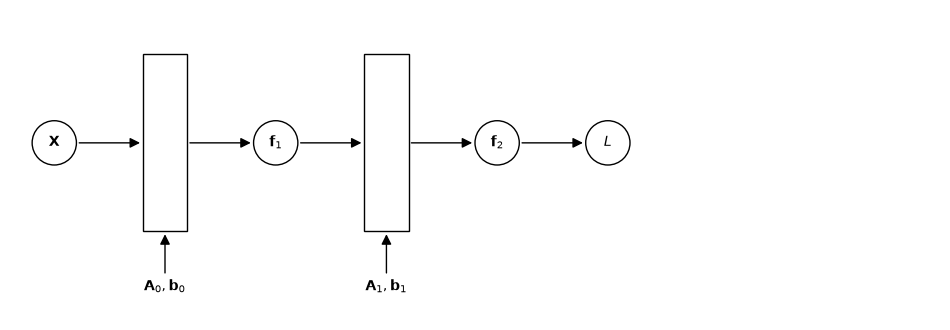

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12,12))

start_x = 0
radius = 0.5
shift = 1.5
arrowstyle = '-|>, head_length=6, head_width=3'

# X
center = start_x
circ = patches.Circle((start_x,2), radius=radius, ec='k', fc='none')
ax.add_patch(circ)
ax.text(center, 2, r"$\mathbf{X}$", ha="center", va="center")

# hidden layer
x_shift = center + radius + shift
width = 1

arrow = patches.FancyArrowPatch(  # Arrow to hidden layer
    posA = (center+radius,2),
    posB = (x_shift,2),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow)

arrow_param1 = patches.FancyArrowPatch(   # Parameters for hidden layer
    posA = (x_shift + width/2, -1),
    posB = (x_shift + width/2, 0),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_param1)
ax.text(x_shift + width/2, -1.25, r"$\mathbf{A}_0, \mathbf{b}_0$", 
        ha='center', va='center')

rect = patches.Rectangle((x_shift, 0), width, 4, ec='k', fc='none')
ax.add_patch(rect)

# f1 
center_1 = x_shift + width + shift + radius

arrow_1 = patches.FancyArrowPatch(
    posA = (x_shift+width,2),
    posB = (center_1 - radius,2),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_1)
ax.text(center_1, 2, r"$\mathbf{f}_1$", ha="center", va="center")

circ_1 = patches.Circle((center_1,2), radius=radius, ec='k', fc='none')
ax.add_patch(circ_1)

# output layer
x_shift_1 = center_1 + radius + shift

arrow_2 = patches.FancyArrowPatch(
    posA = (x_shift_1-shift,2),
    posB = (x_shift_1,2),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_2)

arrow_param2 = patches.FancyArrowPatch(   # Parameters for output layer
    posA = (x_shift_1 + width/2, -1),
    posB = (x_shift_1 + width/2, 0),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_param2)
ax.text(x_shift_1 + width/2, -1.25, r"$\mathbf{A}_1, \mathbf{b}_1$", 
        ha='center', va='center')

rect_1 = patches.Rectangle((x_shift_1, 0), width, 4, ec='k', fc='none')
ax.add_patch(rect_1)

# f2
center_2 = x_shift_1 + width + shift + radius

arrow_3 = patches.FancyArrowPatch(
    posA = (x_shift_1 + width,2),
    posB = (center_2 - radius,2),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_3)

circ_2 = patches.Circle((center_2,2), radius=radius, ec='k', fc='none')
ax.add_patch(circ_2)
ax.text(center_2, 2, r"$\mathbf{f}_2$", ha="center", va="center")

# L
center_3 = center_2 + 2*radius + shift

arrow_4 = patches.FancyArrowPatch(
    posA = (center_2 + radius,2),
    posB = (center_3 - radius,2),
    arrowstyle = arrowstyle,
    fc = 'k'
)
ax.add_patch(arrow_4)

circ_3 = patches.Circle((center_3,2), radius=radius, ec='k', fc='none')
ax.add_patch(circ_3)
ax.text(center_3, 2, r"$L$", ha="center", va="center")


ax.set_xlim(-1,20)
ax.set_ylim(-2,5)
ax.axis('off')
ax.set_aspect('equal')
plt.rcParams['text.usetex'] = True
plt.show()

where:
- $\mathbf{X} \in \mathbb{R}^{N \times M}$ - training data
- $\mathbf{A}_0 \in \mathbb{R}^{N_1 \times N}$ - weight matrix for the hidden layer with $N_1$ layers.
- $\mathbf{b}_0 \in \mathbb{R}^{N_1}$ - bias vector for the hidden layer.
- $\mathbf{f}_1 \in \mathbb{R}^{N_1\times M}$ - activation function for the hidden layer, whose value is the input to the output layer.
- $\mathbf{A}_1 \in \mathbb{R}^{1\times N_1}$ - weight matrix for the output layer with 1 layer.
- $\mathbf{b}_1 \in \mathbb{R}$ - bias term for the output layer.
- $\mathbf{f}_2 \in \mathbb{R}^{1\times M}$ - activation function for the output layer.
- $L\in \mathbb{R}$ - cost function

### Forward Pass
let
$$
\begin{align}
\mathbf{z}_1 &\coloneqq \mathbf{A}_0\mathbf{X} + \mathbf{b}_0 \in \mathbb{R}^{N_1 \times M} \\
\mathbf{f}_1 &\coloneqq \sigma(\mathbf{z}_1) \in \mathbb{R}^{N_1 \times M} \\
\mathbf{z}_2 &\coloneqq \mathbf{A}_1\mathbf{f}_1 + \mathbf{b}_1 \in \mathbb{R}^{1\times M} \\
\mathbf{f}_2 &\coloneqq \sigma(\mathbf{z}_2) \in \mathbb{R}^{1 \times M} \\
\end{align}
$$
and
$$
\begin{align}
\mathbf{e}^{(j)} &\coloneqq \mathcal{L}(\mathbf{f}_2^{(j)},\mathbf{y}^{(j)}) = -\mathbf{y}^{(j)}\log{\mathbf{f}_2^{(j)}} - (1-\mathbf{y}^{(j)})\log{(1-\mathbf{f}_2^{(j)})} \\
L &\coloneqq \frac{1}{M}\sum_{j}\mathbf{e}^{(j)}
\end{align}
$$

### Backward Pass
by successively applying the chain rule and simplifying,
$$
\begin{align}
d\mathbf{A}_1 &= \frac{1}{M}(\mathbf{f}_2-\mathbf{y})\mathbf{f}_1^T \\
d\mathbf{b}_1 &= \frac{1}{M}(\mathbf{f}_2 - \mathbf{y})\mathbf{1}_{M}\\
d\mathbf{A}_0 &= \frac{1}{M}\mathbf{A}_1^{T}(\mathbf{f}_2 - \mathbf{y})\odot \mathbf{f}_1'(\mathbf{z}_1) \mathbf{X}^{T} \\
d\mathbf{b}_0 &= \frac{1}{M}\mathbf{A}_1^{T}(\mathbf{f}_2 - \mathbf{y})\odot \mathbf{f}_1'(\mathbf{z}_1)\mathbf{1}_{M}
\end{align}
$$

### Update
$$
\begin{align}
\mathbf{A}^{(i+1)}_{1} &\coloneqq \mathbf{A}^{(i)}_1 - d\mathbf{A}_1^{(i)} \\
\mathbf{b}^{(i+1)}_{1} &\coloneqq \mathbf{b}^{(i)}_1 - d\mathbf{A}_1^{(i)} \\
\mathbf{A}^{(i+1)}_{0} &\coloneqq \mathbf{A}^{(i)}_0 - d\mathbf{A}_0^{(i)} \\
\mathbf{b}^{(i+1)}_{0} &\coloneqq \mathbf{b}^{(i)}_0 - d\mathbf{b}_0^{(i)} \\
\end{align}
$$

## Implementation - Handwritten Digits

In [21]:
from sklearn.datasets import fetch_kddcup99

dataset = fetch_kddcup99(as_frame=True)

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X_init = dataset.data
y_init = np.where(dataset.target.to_numpy()==b'normal.',0,1)

X_init = X_init.convert_dtypes()

cats = ['protocol_type', 'service', 'flag']
nums = X_init.columns.drop(cats)

for cat in cats:
    X_init[cat] = X_init[cat].astype(str)

stratify_group = X_init['protocol_type'] + " " + X_init["service"] + " " + X_init["flag"]
value_counts = stratify_group.value_counts()
rare_groups = value_counts[value_counts < 2].index

stratify_group = stratify_group.replace(rare_groups, "rare_combination")

X_train, X_test, y_train, y_test = train_test_split(X_init, y_init, test_size=0.2, random_state=42, stratify=stratify_group)

transformer = ColumnTransformer([('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats),
                                 ('scale', StandardScaler(), nums)
                                ])

X_train_t = transformer.fit_transform(X_train).T
X_test_t = transformer.transform(X_test).T
y_train_t = y_train[np.newaxis,:]
y_test_t = y_test[np.newaxis,:]

X_train_t.shape, X_test_t.shape, y_train_t.shape, y_test_t.shape

((117, 395216), (117, 98805), (1, 395216), (1, 98805))

In [66]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_init = cancer.data
y_init = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X_init, y_init, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train_t = scaler.fit_transform(X_train).T
X_test_t = scaler.transform(X_test).T
y_train_t = y_train[np.newaxis,:]
y_test_t = y_test[np.newaxis,:]

X_train_t.shape, y_train_t.shape

((30, 512), (1, 512))

In [68]:
from tqdm import tqdm

def initialize_params(n_nodes, n_features, random_state=42):
    """
    initialize parameters for hidden layer.
    weights matrix are initialized randomly,
    the bias vector will be initialized with zeros
    
    n_features - number of features of features/input matrix
    n_nodes - number of nodes of the hidden layer
    random_state - random_state to be used in the random number generator
    """
    rng = np.random.default_rng(seed=random_state)
    A = rng.random(size=(n_nodes,n_features))
    b = np.zeros(shape=(n_nodes,1))

    return A,b
        
def sigmoid(z):
    return 1/(1+np.exp(-z))

def d_sigmoid(z):
    return sigmoid(z) * (1-sigmoid(z))

def check_shapes(X,y,A0,b0,A1,b1):
    if A0.shape[1] != X.shape[0]:
        raise ValueError("Mismatch between dimension 0 of X and dimension 1 of A0")
        
    elif b0.shape[0] != A0.shape[0]:
        raise ValueError("Dimension 0 mismatch between b0 and A0")
        
    elif A1.shape[1] != A0.shape[0]:
        raise ValueError("Mismatch between dimension 0 of A0 and dimension 1 of A1")

    elif b1.shape != (1,1):
        raise ValueError("b1 must be an array of shape (1,1)")

    return None

def forward_pass(X,A0,b0,A1,b1,y=None):
    """
    X - n features by m samples matrix
    y - 1 by n row vector containing the target variable
    A0 - weights matrix for hidden layer; number of columns must be n_features
    b0 - bias vector for hidden layer; dimensions must be A0.shape[0] by 1
    A1 - weights vector for output layer; number of columns must be the same as number of rows of A0
    b1 - bias term for output layer; must be a scalar
    """
    check_shapes(X,y,A0,b0,A1,b1)
    z1 = (A0 @ X) + b0
    f1 = sigmoid(z1)
    z2 = (A1 @ f1) + b1
    f2 = sigmoid(z2)

    if not isinstance(y,np.ndarray):
        return z1,f1,z2,f2

    else:
        # check final shape
        if f2.shape != y.shape:
            raise ValueError("Dimension mismatch between f2 and y")

        # clip f2 between a minimum and a maximum
        f2_min = 1e-15
        f2_max = 1 - 1e-15
        f2_clipped = np.clip(f2, f2_min, f2_max)
        
        e = -y*np.log(f2_clipped)-(1-y)*np.log(1-f2_clipped)
        L = ((1/X.shape[1]) * np.sum(e,axis=1)).item()
        
        return z1,f1,z2,f2,L

def backward_pass(X,y,A0,b0,A1,b1,forward_results):
    """
    X - n features by m samples matrix
    y - 1 by n row vector containing the target variable
    A0 - weights matrix for hidden layer; number of columns must be n_features
    b0 - bias vector for hidden layer
    A1 - weights vector for output layer; number of columns must be the same as number of rows of A0
    b1 - bias term for output layer; must be a scalar
    forward_results - forward pass results
    """
    z1, f1, z2, f2, L = forward_results
    M = X.shape[1]
    
    dA1 = (1/M) * (f2-y) @ f1.T
    db1 = (1/M) * (f2-y) @ np.ones(shape=(M,1))
    dA0 = (1/M) * ((A1.T @ (f2-y)) * d_sigmoid(z1)) @ X.T
    db0 = (1/M) * ((A1.T @ (f2-y)) * d_sigmoid(z1)) @ np.ones(shape=(M,1))

    return dA0, db0, dA1, db1

def update_params(A0,b0,A1,b1,backward_results,learning_rate=0.1):
    """
    A0 - (n_nodes, n_features) weights matrix for hidden layer
    b0 - (n_nodes, 1) bias vector for hidden layer
    A1 - (1, n_nodes) weights matrix
    b1 - float or int; bias term
    backward_results - backward pass results
    """
    dA0, db0, dA1, db1 = backward_results

    check_dict = {
        '(A0,db0)': A0.shape == dA0.shape,
        '(b0,db0)': b0.shape == db0.shape,
        '(A1,dA1)': A1.shape == dA1.shape,
        'db1': b1.shape == db1.shape
    }
    check_arr = np.array(list(check_dict.values()))
    check = np.all(check_arr)
    if not check:
        argerror = list(np.argwhere(~check_arr).reshape(-1))
        errors = []
        for arg in argerror:
            error = list(check_dict.keys())[arg]
            errors.append(error)
        raise ValueError(f"Mismatch in shapes or type {', '.join(errors)}")

    A0_upd = A0 - learning_rate * dA0
    b0_upd = b0 - learning_rate * db0
    A1_upd = A1 - learning_rate * dA1
    b1_upd = b1 - learning_rate * db1

    return A0_upd, b0_upd, A1_upd, b1_upd

def train_network(X, y, n_nodes=10, tol=1e-6, max_iter=1000, learning_rate=0.1):
    """
    Function to train shallow network with batch gradient descent
    X - training features matrix (n_features, n_samples)
    y - training target matrix (1, n_samples)
    tol - complete training when all of dA0, db0, dA1, db1 are within tolerance.
    max_iter - maximum number of iterations
    """
    # initialize parameters
    n_features = X.shape[0]
    A0, b0 = initialize_params(n_nodes=n_nodes, n_features=n_features)
    A1, b1 = initialize_params(n_nodes=1, n_features=n_nodes)

    pbar = tqdm(range(max_iter))
    for i in pbar:
        forward_results = forward_pass(X,A0,b0,A1,b1,y=y)
        backward_results = backward_pass(X,y,A0,b0,A1,b1,
                                         forward_results)
        A0, b0, A1, b1 = update_params(A0,b0,A1,b1,
                                       backward_results,
                                       learning_rate=learning_rate)

        _, _, _, _, L = forward_results

        if i % int(1e3) == 0:
            pbar.set_postfix({'loss': L})
        
        if abs(L) < tol:
            print(f"Tolerance has been satisfied: loss={L:.7f}")
            break
            
    if max_iter == i + 1:
        print(f"Warning: Maximum number of iterations exceeded - loss={L}")
        
    return A0, b0, A1, b1

def predict(X, A0, b0, A1, b1):
    """
    predict X_test using parameters A0, b0, A1, b1
    X - (n_features, n_samples) test features matrix
    """

    _, _, _, proba = forward_pass(X,A0,b0,A1,b1)
    y_pred = np.where(proba>0.5,1,0)
    return y_pred

In [125]:
A0, b0, A1, b1 = train_network(X_train_t,y_train_t, max_iter=int(1e6), n_nodes=16, learning_rate=2e-1, tol=1e-4)

 48%|█████████████████████████████▊                                | 481561/1000000 [01:40<01:48, 4793.80it/s, loss=0.0001]

Tolerance has been satisfied: loss=0.0001000


In [126]:
from sklearn.metrics import classification_report

y_pred = predict(X_test_t, A0, b0, A1, b1).reshape(-1)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       0.97      0.95      0.96        40

    accuracy                           0.95        57
   macro avg       0.93      0.95      0.94        57
weighted avg       0.95      0.95      0.95        57



In [131]:
from sklearn.linear_model import LogisticRegression

y_pred_l = LogisticRegression(max_iter=int(1e4)).fit(X_train, y_train).predict(X_test)
print(classification_report(y_test,y_pred_l))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.98      1.00      0.99        40

    accuracy                           0.98        57
   macro avg       0.99      0.97      0.98        57
weighted avg       0.98      0.98      0.98        57

